# **Project work: A mini segmentation challenge**

<div style="color:#777777;margin-top: -15px;">
<b>Course</b>: MSLS / CO4 |
<b>Version</b>: v1.3 <br><br>
<!-- 10.04.2025, v1.2: Fully refactored -->
<!-- 17.04.2026, v1.3: Introduced word count limits -->
</div>


**Student**: $\Rightarrow$ Livia Vizens, Cyrille Niklaus

**Email**: $\Rightarrow$ vinzeliv@students.zhaw.ch, niklacyr@students.zhaw.ch

**University**: $\Rightarrow$  ZHAW

**Semester**: $\Rightarrow$  2nd Semester

**Date**: $\Rightarrow$  DATE OF SUBMISSION


<br>

## **Abstract**

*This project develops a classical image segmentation pipeline for E. coli colony detection on self-made petri dishes. We then evaluate the generalizability of our method by testing it on images from the AGAR dataset, assessing how well our segmentation strategy transfers across different imaging conditions and experimental setups. This comparison helps identify whether our approach can reliably handle diverse colony images beyond our controlled lab environment. Further, this project acts as a benchmark segmentation and bounding box approach for a deep learning applications related to the Project work of the module "Deep Learning".*



<br><br>

----

## **Table of contents**
<!-- Unfortunately, the following does not always work correctly -->
* [1. Dataset](#sec_dataset)  
* [2. Preprocessing](#sec_preprocessing)  
* [3. Manual segmentation](#sec_manual_segmentation)  
* [4. Automated segmentation](#sec_automated_segmentation)  
* [5. Evaluation](#sec_evaluation)  
* [6. Discussion](#sec_discussion)  
* [Appendix: Hints](#sec_hints)  


---

## **Prerequisites / Setup**

$\Rightarrow$ Special setup instructions, imports and configurations go here.


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2 as cv
import PIL
from PIL import Image
from matplotlib.pyplot import title
from pandas.core.dtypes import astype
import os



# Jupyter / IPython configuration:
# Automatically reload modules when modified
%load_ext autoreload
%autoreload 2

# Enable vectorized output (for nicer plots)
%config InlineBackend.figure_formats = ["svg"]

# Inline backend configuration
%matplotlib inline

# Enable this line if you want to use the interactive widgets
# It requires the ipympl package to be installed.
#%matplotlib widget

import sys
sys.path.insert(0, "../")
import tools


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---


<a id='sec_dataset'></a>

## **Dataset**

*$\Rightarrow$ Describe your dataset.*

### **Requirements**
* Provide a dataset with at least 10 image samples.
* The dataset must be no larger than 200 MB. If it exceeds this size, please contact the tutor in advance.
* Ensure that you have the rights to use and share the data (check the usage license).
* The images should clearly show a recognizable structure of interest.
* Avoid datasets with too much variation.
* Each student/team must use a different dataset!



---

<a id='sec_preprocessing'></a>

## **Preprocessing**

*$\Rightarrow$ Describe the pre-processing steps applied to enhance the input images.*

*Note: The specific steps will depend on your dataset and the intended application.*

### **Instructions:**
* Improve image quality by reducing noise, adjusting contrast, or normalizing intensity.
* Standardize image dimensions and formats for consistent input to analysis pipelines.
* Highlight or isolate relevant structures to support downstream processing.




### **Image Cropping:**
* Our self-made petri dished are imaged by using a scanner.
* In order to separate the single petri dishes into one image each, we crop the original scan.
* One petri dish has the diensions 4150, 4150, 3
* The images are combined to a list, for further processing **(to implement)**



In [ ]:
# Read test image
test_img = cv.imread("high_res_color_restore.tif", cv.IMREAD_COLOR)
# Change BGR to RGB representation
test_img = cv.cvtColor(test_img, cv.COLOR_BGR2RGB)
# crop the petri dish
test_img_cropped = test_img[4700:8850, 3450:7600].copy()
# print some stats
print(test_img_cropped.shape) # 4150, 4150 -> dimensions of a petri dish
print(test_img_cropped.dtype)
# Show our test images
plt.imshow(test_img) # used this because you can see the pixel range of the whoel image
plt.show()
#tools.show_image(test_img)
tools.show_image(test_img_cropped)

### **Cropping of Image containing multiple plates**

(13655, 9816, 3)
(4150, 4150, 3)
uint8


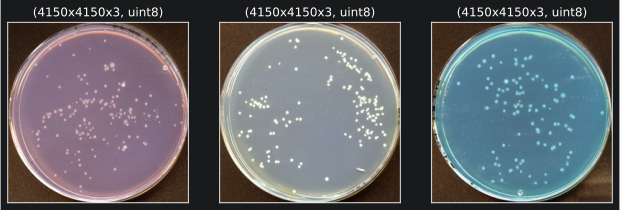

In [2]:
# Read test image
multi_plate = cv.imread("multi_plate.tif", cv.IMREAD_COLOR)
print(multi_plate.shape)
# Change BGR to RGB representation
multi_plate = cv.cvtColor(multi_plate, cv.COLOR_BGR2RGB)
# crop the petri dish
multi_crop_red = multi_plate[700:4850, 1000:5150].copy()
multi_crop_white = multi_plate[4900:9050, 1000:5150].copy()
multi_crop_green = multi_plate[9100:13250, 1200:5350].copy()
# print some stats
print(multi_crop_red.shape) # 4150, 4150 -> dimensions of a petri dish
print(multi_crop_red.dtype)
# Show our test images
#plt.imshow(multi_crop_green)
#plt.imshow(multi_crop_green)
#plt.imshow(multi_crop_white)
mult_plates = [multi_crop_red, multi_crop_white, multi_crop_green]
# used this because you can see the pixel range of the whoel image
#plt.show()
#tools.show_image(test_img)
tools.show_image_chain(mult_plates)

### **Quantize images**
* The images of the individual petri dishes are quantized to decrease the number of colors used.
* We tested 4 and 6 bit.

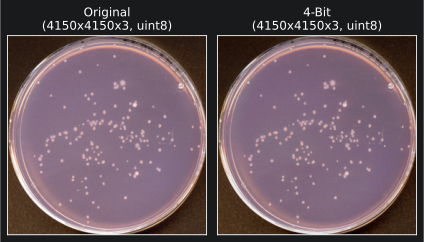

In [3]:
def quantize(image, nbits):
    """Method 1:
    Quantize an image to a lower number of bits. The image must be
    in uint8 format. The number of bits must be between 1 and 8.
    The function works for an arbitrary number of channels.
    """
    assert image.dtype == np.uint8, "Image must be uint8"
    assert nbits > 0 and nbits <= 8, "Invalid number of bits"

    # Create equally sized bins for the 256 levels (per channel).
    # np.digitize(img, bins) returns the bin index for each pixel
    # value, where bins is an array of bin edges: [bins[i], bins[i+1])
    # Note that the first bin with index 0 is [-infinity, bins[0]),
    # and the next bin with index 1 is [bins[0], bins[1]). As the
    # first bin is irrelevant in our case, we need to subtract 1
    # from the returned bin indices (to start from 0).
    #
    # Examples for the bins, depending on the number of bits:
    #   - nbits=8, bins=[0,1,2,...,256]
    #   - nbits=2, bins=[0,64,128,192,256]
    #   - nbits=1, bins=[0,128,256]
    bins = np.arange(0, 256+1, 256 // 2**nbits)
    ret = np.digitize(image, bins) - 1
    # ret is now an array of bin indices, with the reduced number
    # of levels. However, we still store the image in uint8 format,
    # so we need to multiply the bin indices with the bin width.
    ret *= (256 // 2**nbits)
    return ret.astype(np.uint8)

def to_4_bit(image_list):
    to_4_bit_list = []
    for i in image_list:
        img = quantize(i, 4)
        to_4_bit_list.append(img)
    return to_4_bit_list

def to_6_bit(image_list):
    to_6_bit_list = []
    for i in image_list:
        img = quantize(i, 6)
        to_6_bit_list.append(img)
    return to_6_bit_list

imgs_4_bit = to_4_bit(mult_plates)
imgs_6_bit = to_6_bit(mult_plates)

#tools.show_image_chain(imgs_4_bit)
#tools.show_image_chain(imgs_6_bit)
tools.show_image_pair(multi_crop_red, imgs_4_bit[0], title1="Original", title2="4-Bit")

## **Manual window selection for dataset creation**
* Cropped individual 500x500x3 images out of the whole plate image for dataset creation.
* Images contain mostly seperated bacterial colonies. Some contain colonies which are not separated to experiment with some techniques during later processing stages.
* Scratches and dust are part of the images was well.

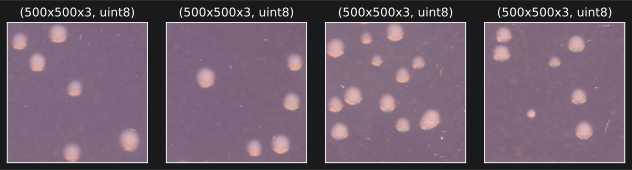

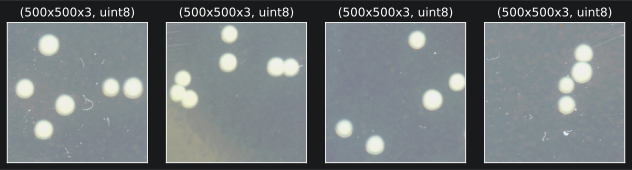

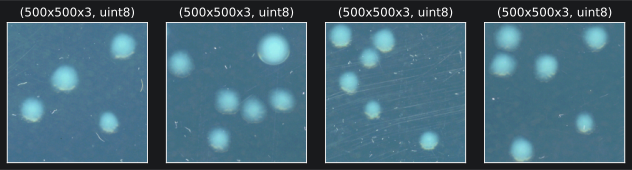

In [4]:
# Red agar petri dish
red_4_bit = imgs_4_bit[0]
red_1 = red_4_bit[1180:1680, 1580:2080].copy()
red_2 = red_4_bit[1275:1775, 2100:2600].copy()
red_3 = red_4_bit[2290:2790, 1620:2120].copy()
red_4 = red_4_bit[2900:3400, 1300:1800].copy()
imgs_red = [red_1, red_2, red_3, red_4]

# White agar petri dish
white_4_bit = imgs_4_bit[1]
white_1 = white_4_bit[2000:2500, 1400:1900].copy()
white_2 = white_4_bit[3050:3550, 900:1400].copy()
white_3 = white_4_bit[2200:2700, 2812:3312].copy()
white_4 = white_4_bit[1150:1650, 2200:2700].copy()
imgs_white = [white_1, white_2, white_3, white_4]

# Green agar petri dish
green_4_bit = imgs_4_bit[2]
green_1 = green_4_bit[700:1200, 1000:1500].copy()
green_2 = green_4_bit[1270:1770, 1325:1825].copy()
green_3 = green_4_bit[3120:3620, 1880:2380].copy()
green_4 = green_4_bit[1875:2375, 2180:2680].copy()
imgs_green = [green_1, green_2, green_3, green_4]

imgs_all_color = [red_1, red_2, red_3, red_4, white_1, white_2, white_3, white_4, green_1, green_2, green_3, green_4]

tools.show_image_chain(imgs_red)
tools.show_image_chain(imgs_white)
tools.show_image_chain(imgs_green)
#tools.show_image(green_4)

### *Denoising*
* Scratches and dust particles are part of the images we use. With denosing, we try to get rid of them.
* We tried several methods, though non was able to perfectly satify. Therefore we tried a combination.
* Below we have an example image of the green set. After using the Non-Local-Means denoising, we get a more uniform background without scratches, while the dust particles are still there.
* Using subsequently a median blur technique, we are able to remove most of the dust particles, while keeping our bacterial colonies.

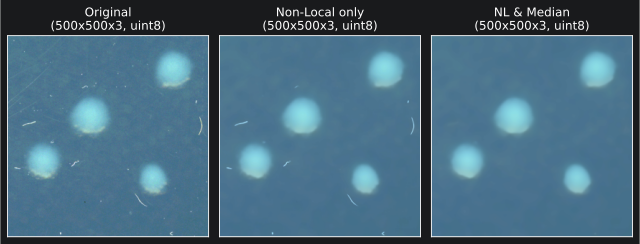

In [7]:
def blur(img):
    img_blur = cv.fastNlMeansDenoisingColored(img, None, 10, 10, 7, 21)
    img_blur = cv.medianBlur(img_blur,9)
    return img_blur


green_NL = cv.fastNlMeansDenoisingColored(imgs_green[0], None,10,10,7,21)
#gr1 = cv.GaussianBlur(imgs_green[0], (7, 7), 0)
#gr2 = cv.bilateralFilter(imgs_green[0], 7, 75, 75)
green_combination = cv.medianBlur(green_NL,9)
blur_process = [imgs_green[0], green_NL, green_combination]

tools.show_image_chain(blur_process, titles = ["Original", "Non-Local only", "NL & Median"])


### **Blurring all sample images**

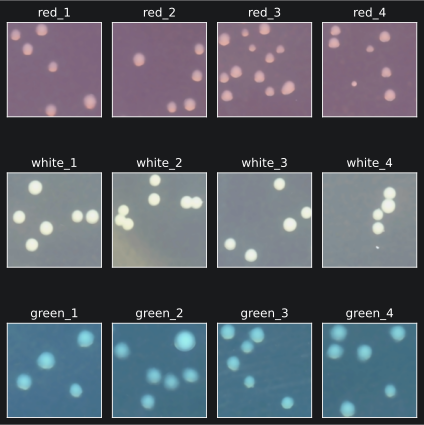

In [8]:
#imgs_red_blur = [blur(i) for i in imgs_red]
#imgs_white_blur = [blur(i) for i in imgs_white]
#imgs_green_blur = [blur(i) for i in imgs_green]

imgs_all_blurred = [blur(i) for i in imgs_all_color]
#tools.show_image_chain(imgs_all_blurred)

results = {}
titles_blur = ["red_1", "red_2", "red_3", "red_4", "white_1", "white_2", "white_3", "white_4", "green_1", "green_2", "green_3", "green_4"]
for i in range(len(imgs_all_blurred)):
    result = imgs_all_blurred[i]
    results[f"{titles_blur[i]}"] = result

tools.show_image_grid(results, suppress_info=True, ncols=4, figsize=(6, 7))

### **Left-over Dust Particles**
* In the example below, we show that the denoising got rid of most noise. Although some artefacts remain.

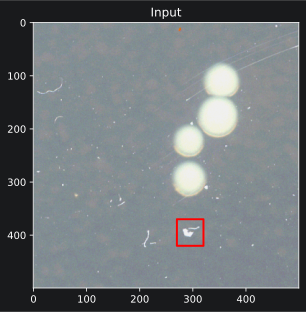

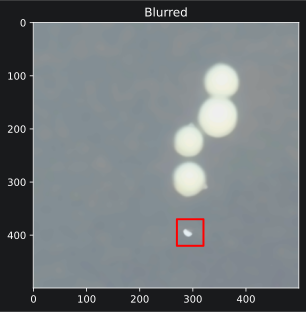

In [27]:
# Display the full image
plt.imshow(imgs_all_color[7])
# Create a rectangle patch
rect = patches.Rectangle((270, 370), 50, 50, linewidth=2, edgecolor='r', facecolor='none')
# Add the rectangle to the plot
plt.gca().add_patch(rect)
plt.title("Input")
plt.show()

plt.imshow(imgs_all_blurred[7])
rect = patches.Rectangle((270, 370), 50, 50, linewidth=2, edgecolor='r', facecolor='none')
plt.gca().add_patch(rect)
plt.title("Blurred")
plt.show()

### **Using Morphological operations**
* Comparing the previous denoising combination with the morphological operation "Opening"
* The Morphological operation "Opening" is able to remove the scratches and dust particles, too.
* The denoising technique produces a less noisy and uniform image. We continue with this.

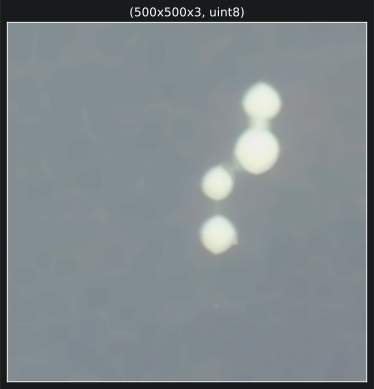

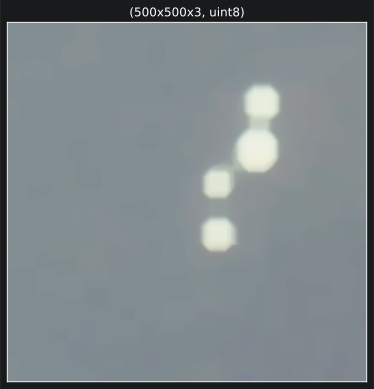

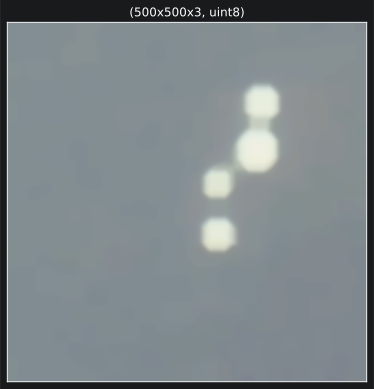

In [136]:
#se = np.ones((3, 3), np.uint8)
se = cv.getStructuringElement(cv.MORPH_RECT, (3, 3))
result = cv.erode(imgs_all_blurred[7].copy(), se, iterations=5)

tools.show_image(result)

#result_blur = cv.medianBlur(result, 9)
#result_blur = cv.GaussianBlur(result, (5, 5), 0)
#result_blur= cv.bilateralFilter(result, 7, 75, 75)
se = cv.getStructuringElement(cv.MORPH_RECT, (5, 5))
ret = cv.morphologyEx(result.copy(), cv.MORPH_OPEN, se, iterations=5)

tools.show_image(ret)

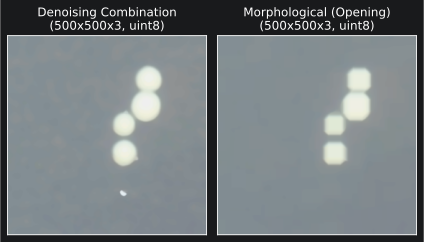

In [127]:
se = cv.getStructuringElement(cv.MORPH_RECT, (30, 30))
ret = cv.morphologyEx(imgs_all_blurred[7].copy(), cv.MORPH_OPEN, se, iterations=1)

tools.show_image_pair(imgs_all_blurred[7], ret, title1="Denoising Combination", title2="Morphological (Opening)")

* Issues with colony seperation and dust particels still present and look like colony (white_4). Try ersosion technique to improve both issues.

### **Using k-means for segmentation**

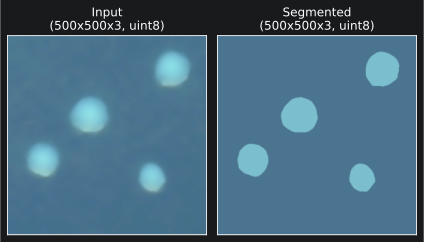

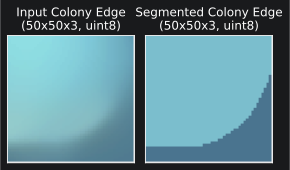

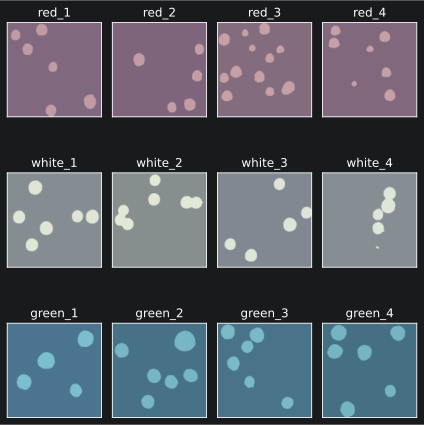

In [125]:
def segment_colonies_kmeans(img, K=2, use_lab=False):
    # Blur the image to reduce noise (step is required here
    # to yield feasible results)
    # img = cv.GaussianBlur(img, (5, 5), 0)

    if use_lab:
        img = cv.cvtColor(img, cv.COLOR_RGB2LAB)

    # 1) Reshape the color pixels into a Mx3 matrix (M: number of pixels)
    #    and convert the data type to float32.
    data = img.reshape(-1, 3).astype(np.float32)

    # 2) Apply the K-means algorithm to the data. Use the cv.kmeans function.
    # Some parameters for the kmeans algorithm (termination criteria):
    criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 0.1)
    ret, label, centers = cv.kmeans(data,
                                    K=K,
                                    bestLabels=None,
                                    criteria=criteria,
                                    attempts=10,
                                    flags=cv.KMEANS_PP_CENTERS)
    # label contains the cluster index for each pixel
    # centers contains the cluster centers (colors!)

    # 3) Reshape and convert the data back to uint8
    img_seg = centers[label.flatten()].reshape(img.shape).astype(np.uint8)

    if use_lab:
        img_seg = cv.cvtColor(img_seg, cv.COLOR_LAB2RGB)

    # 4) Return the segmented image
    return img_seg


img = green_combination.copy()
img_seg = segment_colonies_kmeans(img, K=2, use_lab=False)
tools.show_image_pair(green_combination, img_seg, title1="Input", title2="Segmented")
tools.show_image_chain([img[200:250, 200:250], img_seg[200:250, 200:250]], titles=["Input Colony Edge", "Segmented Colony Edge"])

imgs_kmeaned = [segment_colonies_kmeans(i) for i in imgs_all_blurred]

results = {}
titles_blur = ["red_1", "red_2", "red_3", "red_4", "white_1", "white_2", "white_3", "white_4", "green_1", "green_2", "green_3", "green_4"]
for i in range(len(imgs_kmeaned)):
    result = imgs_kmeaned[i]
    results[f"{titles_blur[i]}"] = result

tools.show_image_grid(results, suppress_info=True, ncols=4, figsize=(6, 7))

* Using Watershed for segmentation
* Pay attention, it turned out that the resolution of the resized image (1024, 1024) was too low and the watershed algorithm was not able to proccess it correctly.
* I had to use the original image resolution so the watershed algorithm was able to work. Although it still is not able to distinguish overlapping colonies.

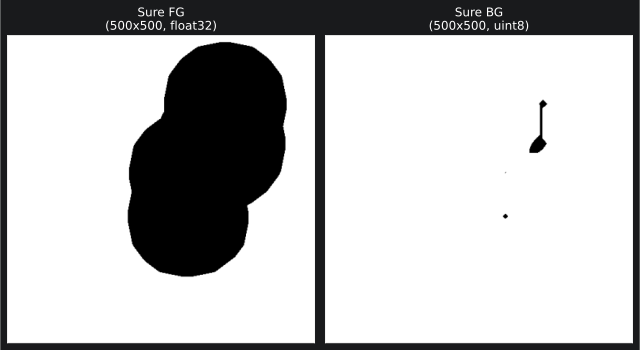

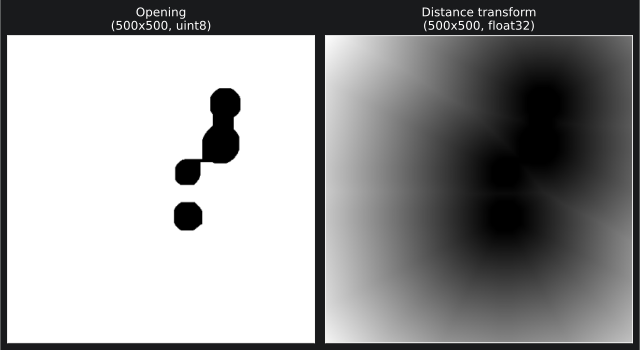

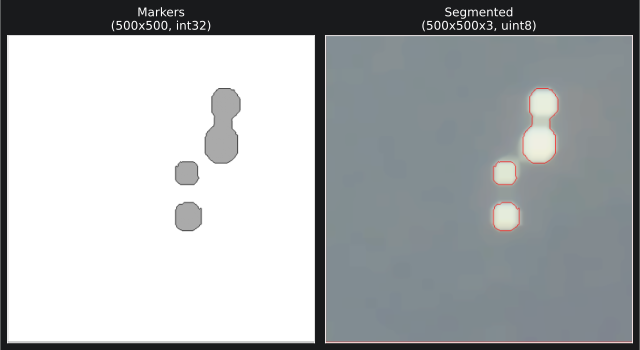

In [132]:
def segment_colonies_watershed(img):

    # img = cv.bilateralFilter(img, 9, 75, 75)
    img = cv.GaussianBlur(img, (5, 5), 0)
    # img = cv.medianBlur(img, 5)

    # tools.show_image(img)

    gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)
    #gray = img[:, :,0]
    ret, thresh = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)

    # Noise removal
    kernel = np.ones((3, 3), np.uint8)
    opening = cv.morphologyEx(thresh, cv.MORPH_OPEN, kernel, iterations=9)

    # Sure background area
    sure_bg = cv.dilate(opening, kernel, iterations=15)

    # Finding sure foreground area
    dist_transform = cv.distanceTransform(opening, cv.DIST_L2, 5)
    #thr = 0.1 * dist_transform.max()
    thr = 75
    ret, sure_fg = cv.threshold(dist_transform, thr, 255, 0)

    tools.show_image_chain([sure_fg, sure_bg], titles=["Sure FG", "Sure BG"])
    tools.show_image_chain([opening, dist_transform], titles=["Opening", "Distance transform"])

    # Finding unknown region
    sure_fg = np.uint8(sure_fg)
    unknown = cv.subtract(sure_bg, sure_fg)

    # Marker labelling
    ret, markers = cv.connectedComponents(sure_fg)

    # Add one to all labels so that sure background is not 0, but 1
    markers = markers+1

    # Now, mark the region of unknown with zero
    markers[unknown==255] = 0

    markers = cv.watershed(img, markers)
    img[markers == -1] = [255, 0, 0]

    return markers, img


#img = test_img_cropped[1200:1400, 1200:1400].copy()
img = ret.copy()
markers, result = segment_colonies_watershed(img)
tools.show_image_chain([markers, result],
                       titles=["Markers", "Segmented"])

# Region where colonies overlap: color_cropped_resized[300:350, 300:350]

### **Gray-scaling & Resizing:**
* The imgeas in the image list are processed to a weighted gray-scaled images. Then, they are resized, in order to lower computation.
* They are returned as np.array
* Below you can find some illustrations about how the chromatic variance between petri dishes influences the grayscale.
* For green/blueish background, gray-scaling improved the differentiation between background and colony.




In [ ]:
img_to_process = [test_img_cropped]
def process_image(img, size=(1024, 1024), to_grayscale=True):
    """Process image: convert to grayscale, resize, return as NumPy array."""
    if to_grayscale:
        img = (img @ [0.299, 0.587, 0.114]).astype(np.uint8)
    return np.array(PIL.Image.fromarray(img).resize(size))

# Process list (if several images to process)
imgs_list = [process_image(i) for i in img_to_process]

# Process test images (to illustrate the difference) -> gray much better for differentiation
gray_cropped_resized = process_image(test_img_cropped)
color_cropped_resized = process_image(test_img_cropped, to_grayscale=False)

# Display images and ROIs
tools.show_image_pair(gray_cropped_resized, color_cropped_resized)
tools.show_image_pair(gray_cropped_resized[200:250, 200:250], color_cropped_resized[200:250, 200:250])

### **Histogram:**
* Below we see the distribution of shades of gray in our image.
* We see a the majority is between 130 and 170.
* We illustraded how equalization decreases the ability to differentiate between colony and background.




In [ ]:
hist, bins = np.histogram(gray_cropped_resized.flatten(), bins=256, range=[0,256], density=True)
cdf = hist.cumsum()
hist /= hist.max()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].imshow(gray_cropped_resized, cmap="gray")
axes[0].axis("off")
axes[1].plot(hist, label="Histogram (normalized)")
axes[1].plot(cdf, label="CDF")
axes[1].set_xlabel("Pixel value")
axes[1].legend();


# Apply histogram equalization
gray_equalized = cv.equalizeHist(gray_cropped_resized.copy())
hist_equalized, bins = np.histogram(gray_equalized.flatten(),
                                    bins=256, range=[0,256],
                                    density=True)
cdf_equalized = hist_equalized.cumsum()
hist_equalized /= hist_equalized.max()
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(gray_equalized, cmap="gray")
axes[0].axis("off")
axes[1].plot(hist_equalized, label="Histogram (normalized)")
axes[1].plot(cdf_equalized, label="CDF")
axes[1].set_xlabel("Pixel value")
axes[1].legend();

# No improvement when applying equalization.
tools.show_image_pair(gray_cropped_resized[200:250, 200:250], gray_equalized[200:250, 200:250])

### **Masking:**
* Since the petri dish in the image is round, the corner parts, displaying only background, are not necessary.
* We masked the background for further image processing.

In [ ]:
def background_masking(img, cx, cy, r):
    mask = np.zeros(img.shape[:2], dtype=np.uint8)
    mask = cv.circle(mask, (cy, cx), r, 255, -1)
    mask = mask.astype(bool)
    img_masked = img.copy()
    img_masked[~mask] = 0
    return img_masked

"""
# Process list of images
imgs_masked = [background_masking(i, 512, 512, 512) for i in imgs_list]
"""

img2_masked = background_masking(gray_cropped_resized, 512, 512, 512)

tools.show_image_pair(gray_cropped_resized, img2_masked, title1="Original", title2="Masked")

### *Sharpening*

* in order to enhance image edges we apply a Laplacian Filter
* unsure about outcome. We see a ring around edge. But will it help?

In [ ]:
kernel = [[0, 1, 0], [1, -4, 1], [0, 1, 0]]
kernel = np.asarray(kernel)
#kernel1 = [[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]
#kernel1 = np.asarray(kernel1)

def sharp(img, kernel):
    img_sharp = cv.filter2D(img, ddepth=-1, kernel=kernel)
    img_sharp = np.abs((img-img_sharp))
    return img_sharp

img_sharp = sharp(img_mask_blur, kernel)

"""
imgs_sharp = [sharp(i, kernel] for i in imgs_blurred]
"""

tools.show_image_pair(img_mask_blur[200:250, 200:250], img_sharp[200:250, 200:250],
                      title1= "img_mask_blur",
                      title2="img_sharp")

### Background removal

* Tried to remove background using the RemBG package but somehow I had issues with the installation.
* Since the background removal anyway does not work for the hematological images, which seem kind of similar to our data set, I skipped the step.

In [ ]:
"""from rembg import remove, new_session

# Create session explicitly
session = new_session()

# Then use it
from PIL import Image
input_img = Image.open("high_res_color_restore.tif")
output_img = remove(input_img, session=session)
output_img.save("output.png")
"""

### Thresholding

* Tried some thresholding techniques

In [ ]:
res1, th1 = cv.threshold(img_mask_blur, 200, 255, cv.THRESH_BINARY)

tools.show_image(th1)
tools.show_image_pair(img_mask_blur[200:250, 200:250], th1[200:250, 200:250], title1="img_mask_blur", title2="binary_threshold")

* Using color channels for segmentation

In [ ]:
img = color_cropped_resized.copy()
tools.show_image_chain([img[:,:,0], img[:,:,1], img[:,:,2]],
                       titles=["R", "G", "B"], normalize=False)

def segment_colonies_blue(img, return_masks=False):
    """Segment white colonies on blue background."""

    # Smooth the image (to reduce noise)
    img = cv.bilateralFilter(img, 7, 75, 75)

    # Convert to grayscale for general brightness
    gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

    # Extract background (blue) - blue channel is high, red/green are low
    thr_bg, mask_bg = cv.threshold(img[:,:,2], 220, 255, cv.THRESH_BINARY)  # Blue channel high

    # Extract white colonies - all channels high equally
    # White has high R, G, B. Blue background has low R/G, high B
    thr_white, mask_white = cv.threshold(gray, 150, 255, cv.THRESH_BINARY)

    # Refine: colonies are white (high R and G), background is blue (low R/G)
    mask_red_green = (img[:,:,0] > 200) & (img[:,:,1] > 200)  # Red and Green high
    mask_colonies = mask_white.astype(bool) & mask_red_green & ~mask_bg.astype(bool)

    # Create result image
    result = np.ones_like(img) * 255
    result[mask_colonies] = [0, 165, 255]  # Orange color for colonies
    result[mask_bg.astype(bool)] = [255, 0, 0]  # Blue color for background

    if return_masks:
        return result, mask_bg, mask_colonies
    else:
        return result

def segment_colonies_flexible(img, return_masks=False):
    """Segment white colonies from any background using color difference."""

    img = cv.bilateralFilter(img, 9, 75, 75)

    # Method: Colonies are white (R ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ G ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ B high)
    # Background is colored (one channel dominates)

    # Calculate color variance: how different are the channels?
    r = img[:,:,0].astype(float)
    g = img[:,:,1].astype(float)
    b = img[:,:,2].astype(float)

    # White has low variance (all channels similar)
    # Colored background has high variance (channels different)
    variance = np.var([r, g, b], axis=0)

    # Threshold: low variance = white colonies
    mask_colonies = variance < 500  # Adjust this value

    # Also require sufficient brightness
    gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)
    mask_colonies = mask_colonies & (gray > 150)

    # Create result
    result = img.copy()
    result[~mask_colonies] = [0, 0, 0]  # Black out background

    if return_masks:
        return result, mask_colonies
    else:
        return result


# Compute segmentation
result, mask = segment_colonies_flexible(color_cropped_resized.copy(), return_masks=True)
tools.show_image_chain([color_cropped_resized, result],
                       titles=["Input", "Colonies Detected"])


In [ ]:
tools.show_image_pair(color_cropped_resized[200:250, 200:250], result[200:250, 200:250], title1="Input", title2="Colonies Detected")

In [ ]:
tools.show_image(result[1200:1400, 1200:1400])

---

<a id='sec_manual_segmentation'></a>

## **Manual segmentation**

*$\Rightarrow$ Describe the manual segmentation step*


### **Instructions:**
* Use a suitable tool to manually segment the structures of interest.
* These segmentations will be needed for further analysis (or model training).
* If your dataset already includes segmentation masks, you still need to demonstrate how such masks can be created manually.

---

<a id='sec_automated_segmentation'></a>

## **Automated Segmentation**

*$\Rightarrow$ Describe how the images are segmented using Python.*

### **Instructions:**
* Perform the segmentation in Python.
* You may use external libraries or tools (e.g., OpenCV, scikit-image).
* Implement a function `segment(image, ...)` that takes an image as input and returns a segmentation mask for the structure of interest.


---

<a id='sec_evaluation'></a>

## **Evaluation**

*$\Rightarrow$ Describe the evaluation of your results.*

### **Instructions:**
* Select an evaluation method to compare two binary segmentation masks and quantify how well they match (e.g., using the Dice score).
* Hint: Implement a function `evaluate(mask1, mask2)` that returns the chosen evaluation score(s).
* Calculate the mean and standard deviation of the scores across the entire dataset.



---

<a id='sec_discussion'></a>

## **Discussion**

*$\Rightarrow$ Briefly discuss your results and share your key observations and your experiences and leaernings.*



---

<a id='sec_references'></a>

## **References**

*$\Rightarrow$ List all relevant references (as URLs).*

*Also, clearly state whether you used generative AI tools (e.g., ChatGPT, GitHub Copilot) and describe how they were used.*



<br><br><br><br><br><br><br><br>

---

<a id='sec_hints'></a>

## **Appendix: Hints**

### **Markdown / HTML**

The following tutorials might be useful if you are not yet familiar with Markdown:

- [Quick overview](https://www.writethedocs.org/guide/writing/markdown/)
- [Markdown GitHub-style](https://docs.github.com/en/get-started/writing-on-github/getting-started-with-writing-and-formatting-on-github/basic-writing-and-formatting-syntax)
- [More detailed tutorial](https://www.datacamp.com/tutorial/markdown-in-jupyter-notebook)

By the way: In Markdown cells, you can also use simple HTML (e.g., `<key>...</key>` blocks) to gain more control over formatting.





### **Display images**

You may want to display your data, if possible. Here are a few ways to do that:

An easy method for displaying 2D images is using the [**Pillow**](https://pillow.readthedocs.io/en/stable/) library:

In [ ]:
# Option 1: Display an image with Pillow
path = "../data/images/kidney-cells-lowres.jpg"
image = PIL.Image.open(path)
display(image)                  

If you are working with the data as a NumPy array (e.g., when using the OpenCV interface), you can also display it using **matplotlib**.

In [ ]:
# Option 2: OpenCV / Matplotlib
path = "../data/images/ct-brain-slices.jpg"
image = cv.imread(path)
plt.imshow(image)
plt.axis("off")
plt.show()

For convenience, we also provide functions `display_image()` and `show_image()` the **tools** library, which includes various utilities used throughout this course.

In [ ]:
# Option 3a: Directly display a file
path = "../data/images/kidney-cells.jpg"
tools.display_image(path, scale=0.5)

# Option 3b: Similar, but with more options (e.g. title, frame, etc.)
tools.show_image(path, scale=0.5, 
                 title="Kidney cells", 
                 title_kwargs=dict(size=16, weight="bold", color="#7E487A"))

<br>
<br>


### **Display overlays**

When segmenting images, you may want to overlay the input image with the segmentation mask.  
There are several ways to do this ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ here are a few ideas:


In [ ]:
################################################
# Idea 1: Overlay a color on a grayscale image
################################################

# Enforce a (3-channel) color image
path_image = "../data/images/neurons-cultured.jpg"
image = cv.imread(path_image, cv.IMREAD_COLOR)
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# Mask image
path_mask = "../data/images/neurons-cultured-mask.png"
mask = cv.imread(path_mask, cv.IMREAD_GRAYSCALE)

# Create overlay (RGB)
overlay_color = [255, 0, 0]
overlay_alpha = 0.3
overlay = image.copy()
overlay[mask > 0] = overlay_color
overlay = cv.addWeighted(image, 1 - overlay_alpha, overlay, overlay_alpha, 0)

# Display the images next to each other using a convenience function
tools.show_image_chain((image, overlay), titles=("Input", "Overlay"))

In [ ]:
################################################
# Idea 2: Overlay contours on a grayscale image
################################################

overlay_color = [255, 255, 0]
line_width = 1
contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
image_contours = image.copy()
cv.drawContours(image_contours, contours, -1, overlay_color, line_width)
tools.show_image_chain((image, image_contours), titles=("Input", "Contours"))

An advanced example: We can colorize different contours using distinct colors.

#### ***Strategy:***
- Use connected component labeling to assign a unique integer label to each region.
- Map each label to a different color by encoding it in the hue channel (in the HSV color space).
- Extract contours from the mask (ensure the mask is binary).
- Draw the contours with their assigned colors onto the original image.


In [ ]:
################################################
# Idea 3: Use colorized contours
################################################

# This will contain the result
image_contours = image.copy()

# Compute the "connected components" (= separate objects in the mask)
n_labels, labels = cv.connectedComponents(mask)

# Assign a different color to each label in the hue channel (HSV color space)
hue = np.uint8(150*labels/np.max(labels))
blank = 255*np.ones_like(hue)
labels = cv.merge([hue, blank, blank])

# Convert from HSV color space to RGB
labels = cv.cvtColor(labels, cv.COLOR_HSV2RGB)
# Set the background label (labels==0) to black
labels[labels==0] = 0

#﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿Create a mask of the contours
line_width = 1
contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
mask_contours = cv.drawContours(np.zeros_like(mask), contours, -1, 255, line_width)

# Assign the colored labels only along the contours
image_contours[mask_contours>0] = labels[mask_contours>0]

# Display the result
tools.show_image_chain((image, image_contours), titles=("Input", "Labeled contours"))

<br>
<br>

### **How to convert a Jupyter notebook into a HTML:**

- Don't forget to **save your notebook** before converting!
- Install the conversion tool (if not already installed): `pip install nbconvert`
- Convert the notebook to an HTML file: `jupyter nbconvert --to html main.ipynb`  
  The HTML file will be saved in the same folder as your notebook.

In [ ]:
# Make sure you save this notebook, otherwise the HTML 
# output will not contain the latest version!!

# Make sure you have nbcovnert installed
# If not, you can install it with pip:
#       pip install nbconvert --quiet
# Save the notebook as HTML
#       jupyter nbconvert --to html main.ipynb